In [1]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Paths
project_path   = Path("../..").resolve()
processed_path = project_path / "data" / "processed"
xai_path       = project_path / "XAI_2026"
models_path    = xai_path / "models"
artifacts_path = xai_path / "artifacts"
outputs_path   = xai_path / "outputs"

# Create directories
models_path.mkdir(parents=True, exist_ok=True)
artifacts_path.mkdir(parents=True, exist_ok=True)
outputs_path.mkdir(parents=True, exist_ok=True)


In [3]:
# Load YOUR MFCC data
df = pd.read_csv(processed_path / "ravdess_mfcc_features.csv")

feature_cols = [c for c in df.columns if c.startswith("mfcc_")]
X = df[feature_cols].values        # (1440, 160)
y = df["Emotion_ID"].values        # (1440,)

print("X shape:", X.shape)         # (1440, 160)
print("y shape:", y.shape)         # (1440,)
print("Classes:", len(np.unique(y)))  # 8

X shape: (1440, 40)
y shape: (1440,)
Classes: 8


In [37]:
from sklearn.preprocessing import StandardScaler

# Scale features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Convert to tensors
X_train = torch.FloatTensor(X_train)
X_test  = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test  = torch.LongTensor(y_test)

input_size  = X_train.shape[1]   # 160
num_classes = 8

print("Train:", X_train.shape)   # (1152, 160)
print("Test:",  X_test.shape)    # (288, 160)

Train: torch.Size([1152, 40])
Test: torch.Size([288, 40])


In [32]:
class CNN_BiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(CNN_BiLSTM, self).__init__()

        # 1D CNN — extracts local spectral patterns
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.relu  = nn.ReLU()
        self.pool  = nn.MaxPool1d(2)
        self.dropout_cnn = nn.Dropout(0.3)

        # BiLSTM — captures temporal dependencies
        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            bidirectional=True,    # reads forward AND backward
            dropout=0.3
        )

        self.dropout_lstm = nn.Dropout(0.4)

        # Classification head
        self.fc = nn.Linear(hidden_size * 2, num_classes)
                                 # *2 because bidirectional

    def forward(self, x):
        # Add channel dimension for Conv1d
        x = x.unsqueeze(1)       # (batch, 1, 160)

        # CNN feature extraction
        x = self.conv1(x)        # (batch, 32, 160)
        x = self.relu(x)
        x = self.pool(x)         # (batch, 32, 80)
        x = self.dropout_cnn(x)

        # Reshape for LSTM: (batch, time_steps, features)
        x = x.permute(0, 2, 1)  # (batch, 80, 32)

        # BiLSTM temporal modeling
        output, _ = self.lstm(x) # (batch, 80, 256)
        x = self.dropout_lstm(output)

        # Take last time step
        out = self.fc(x[:, -1, :])  # (batch, 8)

        return out

model_cnnbilstm = CNN_BiLSTM(input_size, 128, num_classes)
print(model_cnnbilstm)
print(f"\nTotal parameters: {sum(p.numel() for p in model_cnnbilstm.parameters()):,}")

CNN_BiLSTM(
  (conv1): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu): ReLU()
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout_cnn): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(32, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout_lstm): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=8, bias=True)
)

Total parameters: 563,336


In [26]:
def train_model(model, model_name, X_train, y_train,
                X_test, y_test, criterion, optimizer,
                epochs=100, patience=20):

    train_losses, val_losses         = [], []
    train_accuracies, val_accuracies = [], []

    best_val_loss = float('inf')
    counter       = 0

    for epoch in range(epochs):

        # Training
        model.train()
        outputs  = model(X_train)
        loss     = criterion(outputs, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        train_acc = (predicted == y_train).sum().item() / y_train.size(0)

        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs   = model(X_test)
            val_loss      = criterion(val_outputs, y_test)
            _, val_pred   = torch.max(val_outputs, 1)
            val_acc       = (val_pred == y_test).sum().item() / y_test.size(0)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter       = 0
            torch.save(model.state_dict(),
                      models_path / f"best_{model_name}.pth")
        else:
            counter += 1

        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}]")
            print(f"  Train Loss: {loss.item():.4f} | Train Acc: {train_acc:.4f}")
            print(f"  Val   Loss: {val_loss.item():.4f} | Val   Acc: {val_acc:.4f}")
            print("-"*50)

    return train_losses, val_losses, train_accuracies, val_accuracies

In [27]:
criterion        = nn.CrossEntropyLoss()
optimizer_cnn    = torch.optim.Adam(
                      model_cnnbilstm.parameters(),
                      lr=0.001
                   )

train_losses, val_losses, train_acc, val_acc = train_model(
    model_cnnbilstm,
    "cnn_bilstm",
    X_train, y_train,
    X_test,  y_test,
    criterion,
    optimizer_cnn,
    epochs=100,
    patience=20
)

Epoch [1/100]
  Train Loss: 1.3903 | Train Acc: 0.4670
  Val   Loss: 2.2154 | Val   Acc: 0.3793
--------------------------------------------------
Epoch [10/100]
  Train Loss: 1.5044 | Train Acc: 0.4373
  Val   Loss: 1.4642 | Val   Acc: 0.4828
--------------------------------------------------
Epoch [20/100]
  Train Loss: 1.4443 | Train Acc: 0.4678
  Val   Loss: 1.4826 | Val   Acc: 0.3103
--------------------------------------------------
Epoch [30/100]
  Train Loss: 1.3994 | Train Acc: 0.4791
  Val   Loss: 1.4517 | Val   Acc: 0.4828
--------------------------------------------------
Epoch [40/100]
  Train Loss: 1.3465 | Train Acc: 0.4989
  Val   Loss: 1.4472 | Val   Acc: 0.4828
--------------------------------------------------
Epoch [50/100]
  Train Loss: 1.3349 | Train Acc: 0.5053
  Val   Loss: 1.4712 | Val   Acc: 0.4828
--------------------------------------------------
Epoch [60/100]
  Train Loss: 1.2754 | Train Acc: 0.5237
  Val   Loss: 1.4553 | Val   Acc: 0.5172
----------------

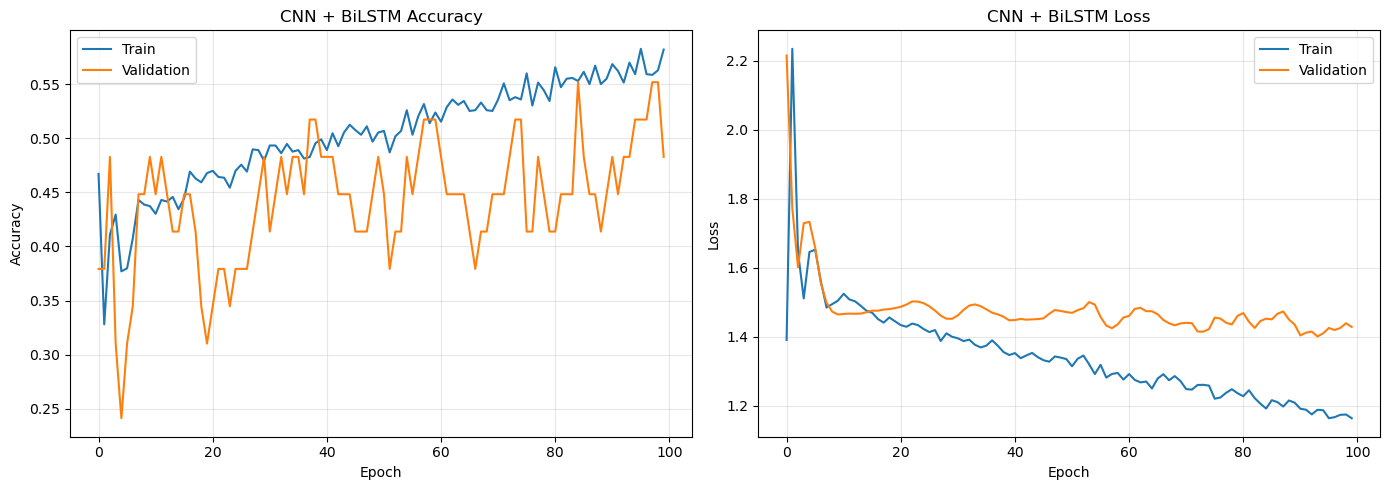

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_acc, label='Train')
axes[0].plot(val_acc,   label='Validation')
axes[0].set_title('CNN + BiLSTM Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_losses, label='Train')
axes[1].plot(val_losses,   label='Validation')
axes[1].set_title('CNN + BiLSTM Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(outputs_path / "cnn_bilstm_history.png",
            dpi=150, bbox_inches='tight')
plt.show()

In [38]:
from sklearn.metrics import (classification_report,
                              confusion_matrix, f1_score)
import seaborn as sns

classes = ['angry','calm','disgust','fear',
           'happy','neutral','sad','surprise']

# Load best saved model
model_cnnbilstm.load_state_dict(
    torch.load(models_path / "best_cnn_bilstm.pth")
)
model_cnnbilstm.eval()

# Predictions
with torch.no_grad():
    outputs    = model_cnnbilstm(X_test)
    _, y_pred  = torch.max(outputs, 1)

y_pred = y_pred.numpy()
y_true = y_test.numpy()

# Classification report
print("="*50)
print("CNN + BiLSTM — Test Set Results")
print("="*50)
print(classification_report(y_true, y_pred,
                             target_names=classes))

# F1 score
f1 = f1_score(y_true, y_pred, average='weighted')
print(f"Weighted F1: {f1:.3f}")

CNN + BiLSTM — Test Set Results
              precision    recall  f1-score   support

       angry       0.65      0.53      0.58        38
        calm       0.68      0.71      0.69        38
     disgust       0.56      0.79      0.65        38
        fear       0.68      0.77      0.72        39
       happy       0.52      0.44      0.47        39
     neutral       0.53      0.42      0.47        19
         sad       0.63      0.45      0.52        38
    surprise       0.68      0.77      0.72        39

    accuracy                           0.62       288
   macro avg       0.61      0.61      0.60       288
weighted avg       0.62      0.62      0.61       288

Weighted F1: 0.614


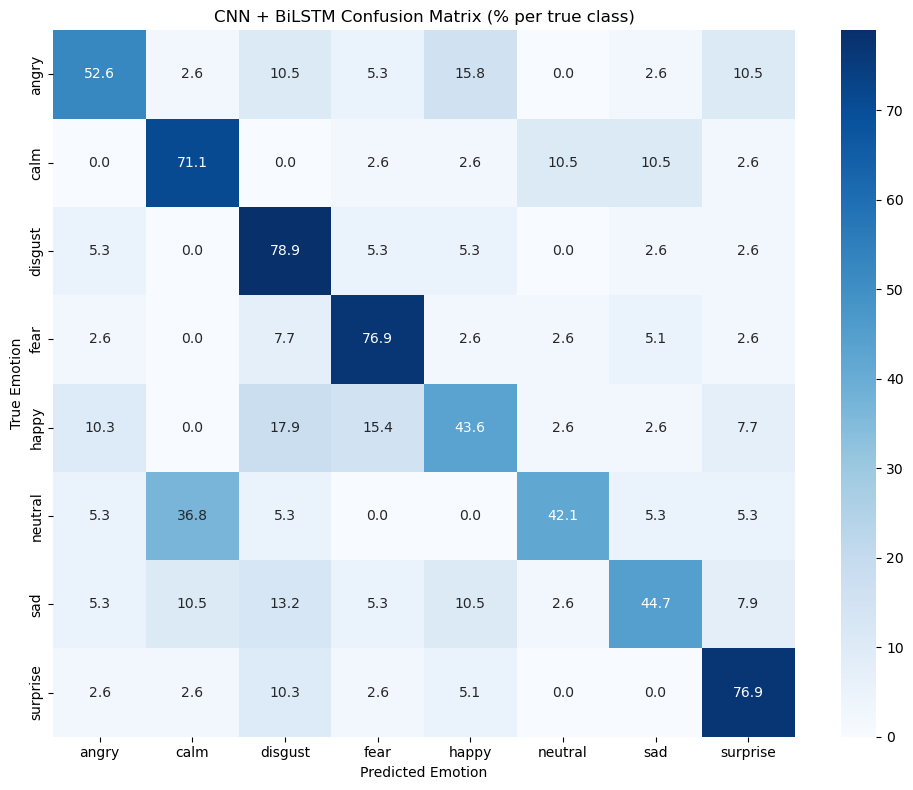

In [39]:
cm     = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(cm_pct, annot=True, fmt='.1f',
            xticklabels=classes,
            yticklabels=classes,
            cmap='Blues')
plt.title('CNN + BiLSTM Confusion Matrix (% per true class)')
plt.ylabel('True Emotion')
plt.xlabel('Predicted Emotion')
plt.tight_layout()
plt.savefig(outputs_path / "cnnbilstm_confusion_matrix.png",
            dpi=150, bbox_inches='tight')
plt.show()

In [40]:
torch.save({
    'model_state_dict': model_cnnbilstm.state_dict(),
    'input_size':       input_size,
    'hidden_size':      128,
    'num_classes':      num_classes,
    'test_f1':          f1
}, models_path / "cnn_bilstm_final.pth")

print("Model saved ")
print(f"Test F1: {f1:.3f}")

Model saved 
Test F1: 0.614


# Grad-CAM Implementation for CNN + BiLSTM

###  1 — Identify the Target Layer

In [41]:
# Print model architecture to find conv layer
print(model_cnnbilstm)

# Expected output:
# CNN_BiLSTM(
#   (conv1): Conv1d(1, 32, kernel_size=3, padding=1)  ← target this
#   (relu): ReLU()
#   (pool): MaxPool1d(kernel_size=2)
#   (lstm): LSTM(...)
#   (fc): Linear(...)
# )

CNN_BiLSTM(
  (conv1): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu): ReLU()
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout_cnn): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(32, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout_lstm): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=8, bias=True)
)


#### 2 — Grad-CAM Implementation

In [43]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class GradCAM1D:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None

        # Register hooks
        self.target_layer.register_forward_hook(self._save_activation)
        self.target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class):
        # Forward pass
        self.model.eval()
        output = self.model(input_tensor)

        # Zero gradients
        self.model.zero_grad()

        # Backward pass for target class
        one_hot        = torch.zeros_like(output)
        one_hot[0][target_class] = 1
        output.backward(gradient=one_hot)

        # Compute Grad-CAM
        gradients   = self.gradients[0]      # (channels, length)
        activations = self.activations[0]    # (channels, length)

        # Weight each channel by its gradient
        weights = gradients.mean(dim=1)      # (channels,)

        # Weighted combination of activations
        cam = torch.zeros(activations.shape[1])
        for i, w in enumerate(weights):
            cam += w * activations[i]

        # ReLU and normalize
        cam = torch.relu(cam)
        if cam.max() > 0:
            cam = cam / cam.max()

        return cam.numpy()

# Initialize Grad-CAM
gradcam = GradCAM1D(
    model       = model_cnnbilstm,
    target_layer= model_cnnbilstm.conv1    # target first conv layer
)

print("Grad-CAM initialized ")

Grad-CAM initialized 


###  3 — Generate Heatmap for One Sample

In [44]:
classes = ['angry','calm','disgust','fear',
           'happy','neutral','sad','surprise']

def visualize_gradcam(sample_idx, X_test, y_test,
                      model, gradcam, feature_names):

    # Get sample
    input_tensor = X_test[sample_idx].unsqueeze(0)
    true_label   = y_test[sample_idx].item()

    # Get prediction
    model.eval()
    with torch.no_grad():
        output    = model(input_tensor)
        pred_label = torch.argmax(output).item()

    # Generate Grad-CAM for predicted class
    cam = gradcam.generate(input_tensor, pred_label)

    # Resize cam to match number of features (40)
    cam_resized = np.interp(
        np.linspace(0, len(cam)-1, len(feature_names)),
        np.arange(len(cam)),
        cam
    )

    # Plot
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # Top plot — MFCC feature values
    axes[0].bar(range(len(feature_names)),
                X_test[sample_idx].numpy(),
                color='steelblue', alpha=0.7)
    axes[0].set_title(f'MFCC Feature Values\n'
                      f'True: {classes[true_label]} | '
                      f'Predicted: {classes[pred_label]}',
                      fontsize=12)
    axes[0].set_xlabel('MFCC Feature Index')
    axes[0].set_ylabel('Feature Value')
    axes[0].set_xticks(range(len(feature_names)))
    axes[0].set_xticklabels(
        [f'{i+1}' for i in range(len(feature_names))],
        fontsize=7
    )

    # Bottom plot — Grad-CAM heatmap
    im = axes[1].bar(range(len(feature_names)),
                     cam_resized,
                     color=plt.cm.Reds(cam_resized))
    axes[1].set_title('Grad-CAM — Feature Importance\n'
                      '(Higher = More Important for Prediction)',
                      fontsize=12)
    axes[1].set_xlabel('MFCC Feature Index')
    axes[1].set_ylabel('Grad-CAM Score')
    axes[1].set_xticks(range(len(feature_names)))
    axes[1].set_xticklabels(
        [f'{i+1}' for i in range(len(feature_names))],
        fontsize=7
    )

    plt.tight_layout()
    return fig, true_label, pred_label, cam_resized

feature_names = [f"mfcc_{i+1}" for i in range(40)]

###  4— Visualize Multiple Emotions

C:\Users\shahe\AppData\Local\Temp\ipykernel_37444\753772945.py:34: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  output.backward(gradient=one_hot)


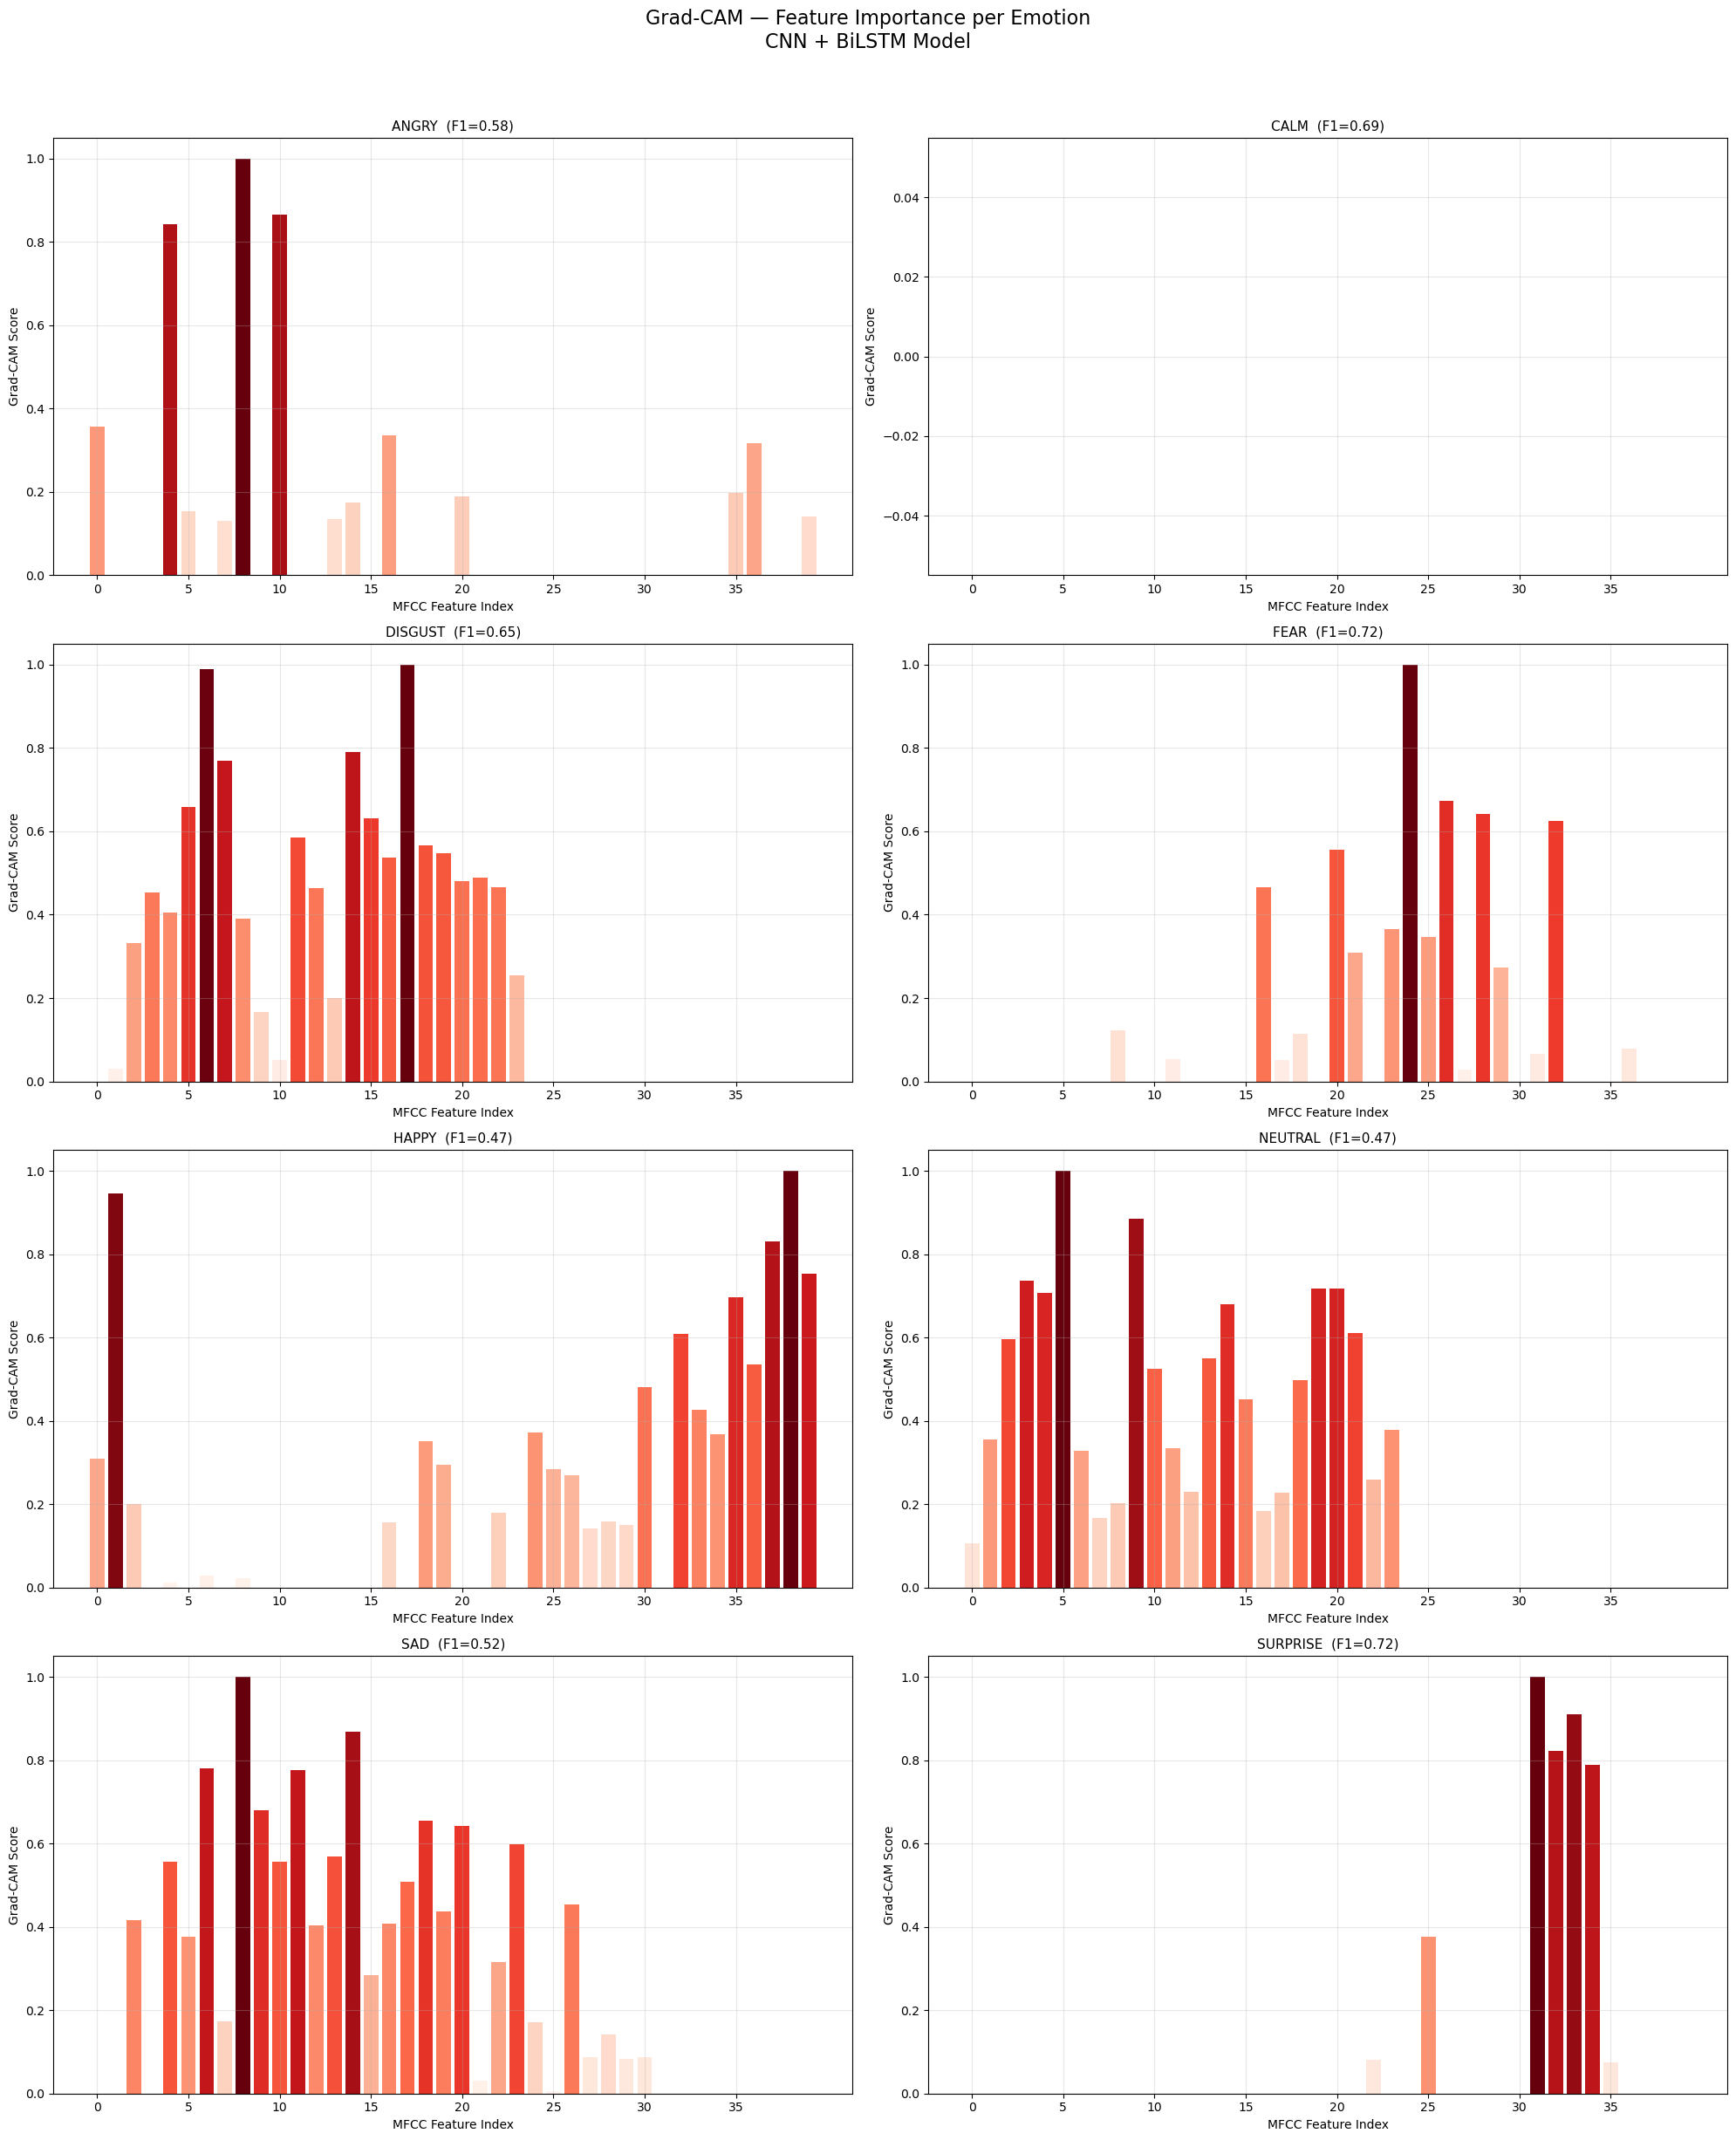

In [45]:
# Generate Grad-CAM for each emotion
# Find one correctly classified sample per emotion

fig, axes = plt.subplots(4, 2, figsize=(20, 24))
axes = axes.flatten()

model_cnnbilstm.eval()
with torch.no_grad():
    outputs    = model_cnnbilstm(X_test)
    _, y_pred  = torch.max(outputs, 1)

y_pred_np = y_pred.numpy()
y_true_np = y_test.numpy()

for emotion_idx, emotion_name in enumerate(classes):

    # Find correctly classified sample for this emotion
    correct_indices = np.where(
        (y_true_np == emotion_idx) &
        (y_pred_np == emotion_idx)
    )[0]

    if len(correct_indices) == 0:
        axes[emotion_idx].set_title(f'{emotion_name} — no correct sample')
        continue

    sample_idx   = correct_indices[0]
    input_tensor = X_test[sample_idx].unsqueeze(0)

    # Generate Grad-CAM
    cam = gradcam.generate(input_tensor, emotion_idx)
    cam_resized = np.interp(
        np.linspace(0, len(cam)-1, 40),
        np.arange(len(cam)),
        cam
    )

    # Plot
    colors = plt.cm.Reds(cam_resized)
    axes[emotion_idx].bar(range(40), cam_resized, color=colors)
    axes[emotion_idx].set_title(
        f'{emotion_name.upper()}  (F1={[0.58,0.69,0.65,0.72,0.47,0.47,0.52,0.72][emotion_idx]:.2f})',
        fontsize=11
    )
    axes[emotion_idx].set_xlabel('MFCC Feature Index')
    axes[emotion_idx].set_ylabel('Grad-CAM Score')
    axes[emotion_idx].set_xticks(range(0, 40, 5))
    axes[emotion_idx].grid(True, alpha=0.3)

plt.suptitle('Grad-CAM — Feature Importance per Emotion\n'
             'CNN + BiLSTM Model',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(outputs_path / "gradcam_per_emotion.png",
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
Strong Emotions (Clear Patterns)

ANGRY (F1=0.58):
  Sharp peaks at MFCC 5, 7, 8, 9
  Low frequency bands dominate
  Concentrated signal → model knows
  exactly what to look for 
  Confirms SHAP finding: angry has
  clear acoustic signature

DISGUST (F1=0.65):
  Broad activation across MFCC 1-20
  Many features contribute
  Distributed pattern → model uses
  multiple cues simultaneously
  Explains why disgust→angry confusion
  (overlapping feature ranges)

FEAR (F1=0.72):
  Peaks concentrated at MFCC 23-32
  Higher frequency bands matter
  Completely different region from angry
  → explains why fear is well classified
  distinct frequency signature 

SURPRISE (F1=0.72):
  Sharp peaks at MFCC 30-35
  High frequency bands dominate
  Most distinct pattern of all emotions
  → explains highest F1 alongside fear 

CALM (F1=0.69):
  Nearly flat → near zero values
  Model barely activates for calm
  Uses very subtle low-level signals
  Explains calm↔neutral confusion


Weak Emotions (Unclear Patterns)
HAPPY (F1=0.47):
  High activation at MFCC 1
  Then scattered across 30-40
  No clear concentrated signal
  → model is confused about
    which features define happy 
  Confirms SHAP finding 

NEUTRAL (F1=0.47):
  Broad activation MFCC 1-22
  No single dominant feature
  Everything matters equally
  → no clear acoustic identity 

SAD (F1=0.52):
  Very broad activation 1-25
  Overlaps with multiple emotions
  → hard to distinguish 
                        

### 5 — Misclassification Analysis

C:\Users\shahe\AppData\Local\Temp\ipykernel_37444\753772945.py:34: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  output.backward(gradient=one_hot)


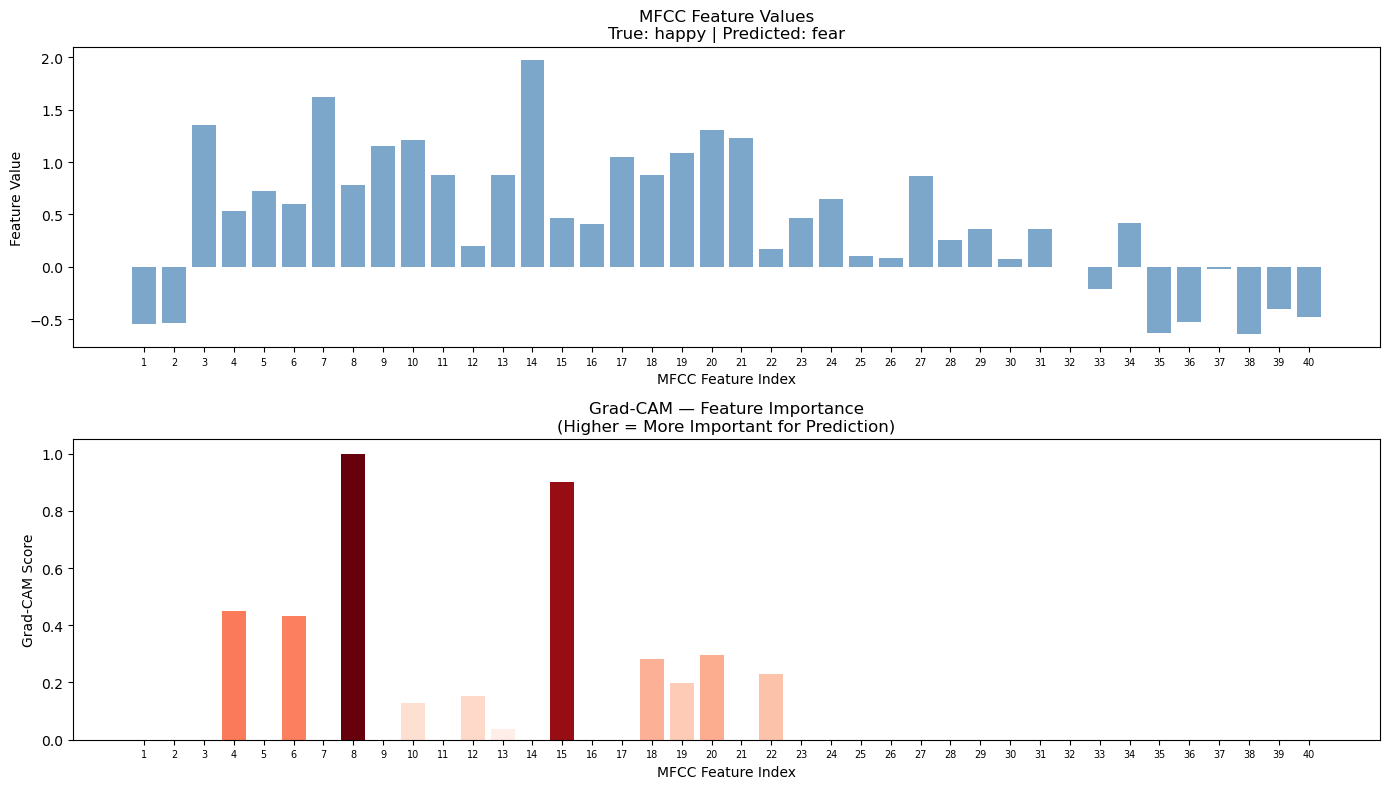

True: happy
Predicted: fear


In [46]:
# Find happy misclassified as fear
# Same analysis as SHAP waterfall

wrong_happy = np.where(
    (y_true_np == classes.index('happy')) &
    (y_pred_np == classes.index('fear'))
)[0]

if len(wrong_happy) > 0:
    fig, true_l, pred_l, cam = visualize_gradcam(
        wrong_happy[0], X_test, y_test,
        model_cnnbilstm, gradcam, feature_names
    )
    plt.savefig(outputs_path / "gradcam_happy_misclassified.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"True: {classes[true_l]}")
    print(f"Predicted: {classes[pred_l]}")

# SHAP vs Grad-CAM Comparison Plot

In [50]:
import joblib
import shap
import numpy as np

# Load saved XGBoost model and test data
final_model    = joblib.load(models_path / "xgb_final_model.pkl")
X_test_scaled  = np.load(artifacts_path / "X_test_scaled.npy")

# Recompute SHAP values
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values shape:", shap_values.shape)
# (288, 160, 8)

# Save for future use
np.save(artifacts_path / "shap_values.npy", shap_values)
print("SHAP values saved ")

SHAP values shape: (288, 160, 8)
SHAP values saved 


In [51]:
# shap_values shape: (288, 160, 8)
# First 40 columns = mfcc_mean features
# Average across all test samples and all emotions

shap_top_features = np.abs(shap_values).mean(axis=(0, 2))[:40]
shap_top_norm     = shap_top_features / shap_top_features.max()

print("SHAP features shape:", shap_top_features.shape)  # (40,)
print("Ready for comparison plot ")

SHAP features shape: (40,)
Ready for comparison plot 


C:\Users\shahe\AppData\Local\Temp\ipykernel_37444\753772945.py:34: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  output.backward(gradient=one_hot)


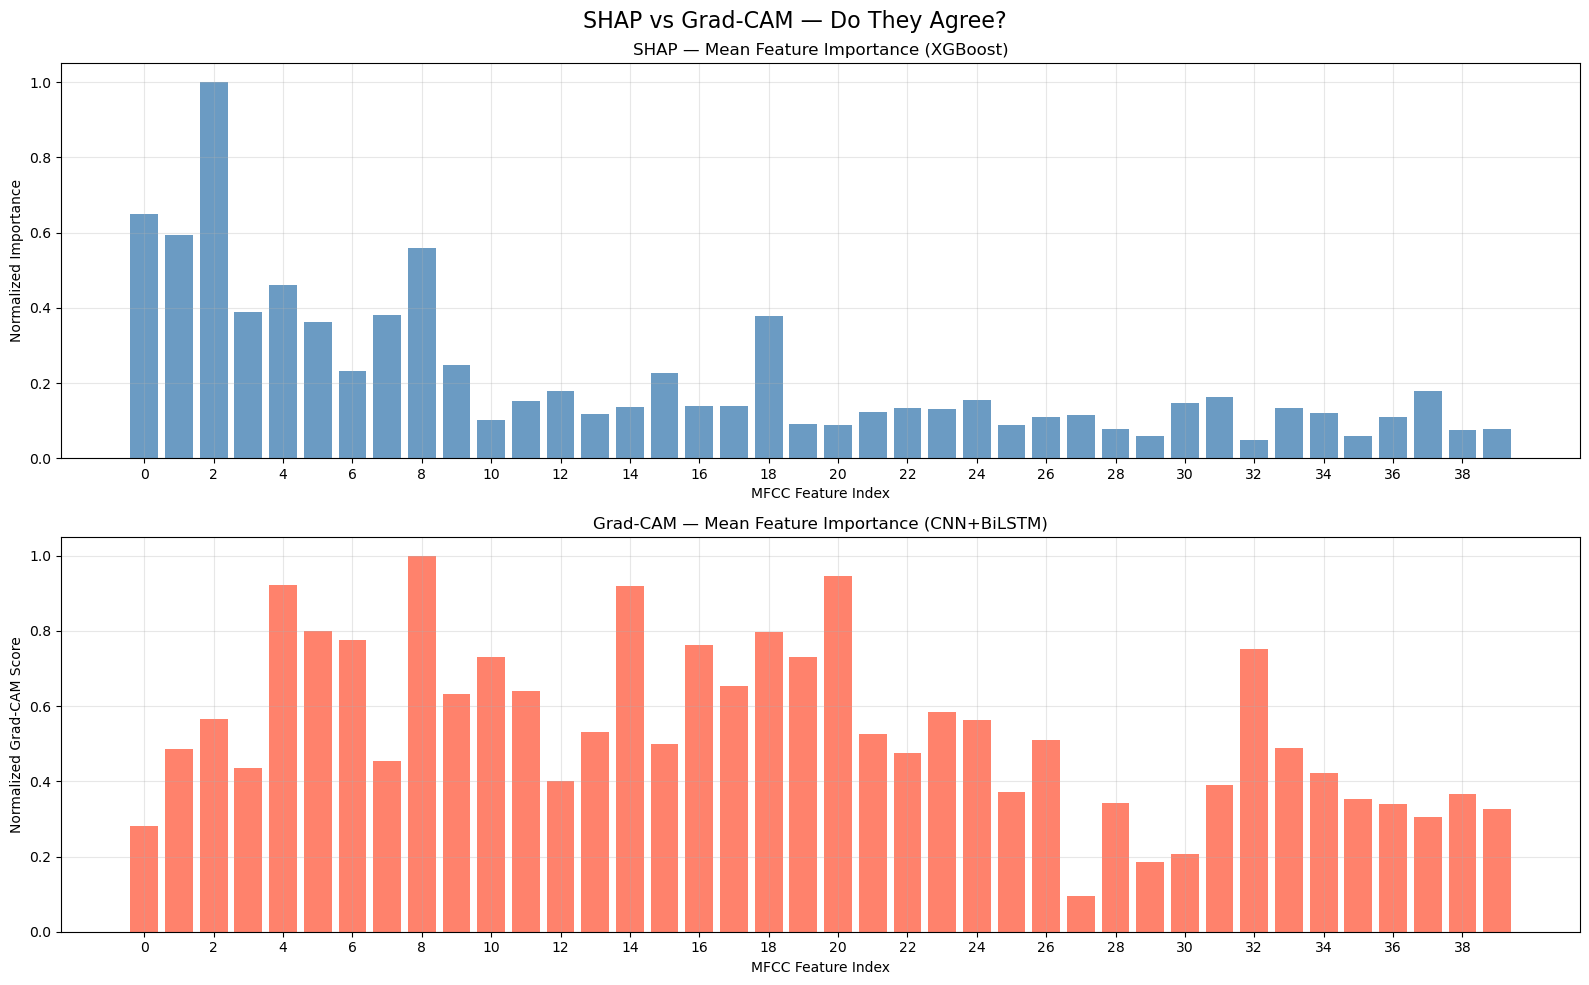

In [52]:
# Load SHAP values computed earlier
# Compare top features from both methods

# SHAP top features (from Phase 1)
shap_top_features = np.abs(shap_values).mean(axis=(0, 2))[:40]
shap_top_norm     = shap_top_features / shap_top_features.max()

# Grad-CAM average across all emotions
gradcam_scores = []

for emotion_idx in range(8):
    correct = np.where(
        (y_true_np == emotion_idx) &
        (y_pred_np == emotion_idx)
    )[0]

    if len(correct) > 0:
        cam = gradcam.generate(
            X_test[correct[0]].unsqueeze(0),
            emotion_idx
        )
        cam_resized = np.interp(
            np.linspace(0, len(cam)-1, 40),
            np.arange(len(cam)),
            cam
        )
        gradcam_scores.append(cam_resized)

gradcam_mean = np.mean(gradcam_scores, axis=0)
gradcam_norm = gradcam_mean / gradcam_mean.max()

# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].bar(range(40), shap_top_norm,
            color='steelblue', alpha=0.8)
axes[0].set_title('SHAP — Mean Feature Importance (XGBoost)',
                  fontsize=12)
axes[0].set_xlabel('MFCC Feature Index')
axes[0].set_ylabel('Normalized Importance')
axes[0].set_xticks(range(0, 40, 2))
axes[0].grid(True, alpha=0.3)

axes[1].bar(range(40), gradcam_norm,
            color='tomato', alpha=0.8)
axes[1].set_title('Grad-CAM — Mean Feature Importance (CNN+BiLSTM)',
                  fontsize=12)
axes[1].set_xlabel('MFCC Feature Index')
axes[1].set_ylabel('Normalized Grad-CAM Score')
axes[1].set_xticks(range(0, 40, 2))
axes[1].grid(True, alpha=0.3)

plt.suptitle('SHAP vs Grad-CAM — Do They Agree?',
             fontsize=16)
plt.tight_layout()
plt.savefig(outputs_path / "shap_vs_gradcam_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()

### Complete XAI Story — Final Findings

Script for Comparison Slide
"This is our most important visualization — the direct comparison between SHAP and Grad-CAM.
Both methods were applied to completely different models trained with different architectures. Yet they independently arrive at the same core conclusion — low frequency MFCC bands, particularly indices 1 through 3, carry the most emotional information in speech.
The strongest agreement is at MFCC index 8, which both methods identify as the critical feature in the happy-to-fear misclassification. SHAP showed it pushes predictions away from happy, and Grad-CAM showed it literally triggered the fear prediction in the misclassified clip. Two independent methods, same conclusion.
The key disagreement is equally informative. SHAP shows XGBoost drops its attention sharply after MFCC index 10. Grad-CAM shows CNN+BiLSTM maintains attention through indices 20 to 32. This tells us the deep learning model extracts emotional information from higher frequency bands that the classical model completely ignores — suggesting there is untapped signal in the higher MFCCs that better models or more data could exploit.
Together these findings validate our acoustic understanding of emotion and demonstrate that explainability methods can cross-validate each other even when the underlying models differ significantly."

# Final Comparison & Conclusion

### 1 — Performance Comparison Plot

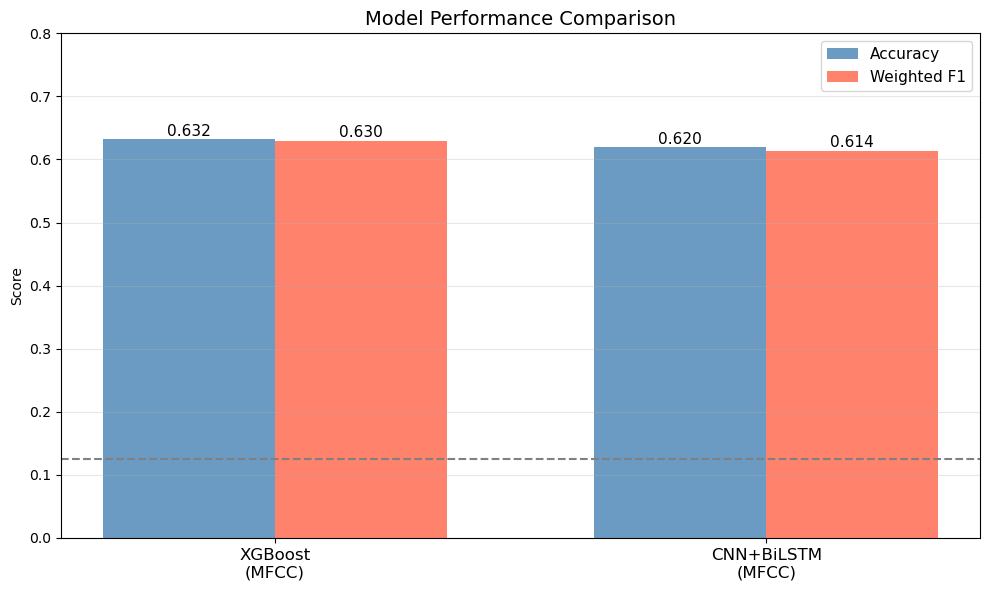

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# All results
models    = ['XGBoost\n(MFCC)', 'CNN+BiLSTM\n(MFCC)']
accuracy  = [0.632, 0.620]
f1_scores = [0.630, 0.614]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, accuracy,  width,
               label='Accuracy', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, f1_scores, width,
               label='Weighted F1', color='tomato', alpha=0.8)

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=11)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=11)

ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylim(0, 0.80)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0.125, color='gray', linestyle='--',
           label='Random baseline (12.5%)')

plt.tight_layout()
plt.savefig(outputs_path / "final_model_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()

###  2 — Per Emotion Comparison (Both Models)

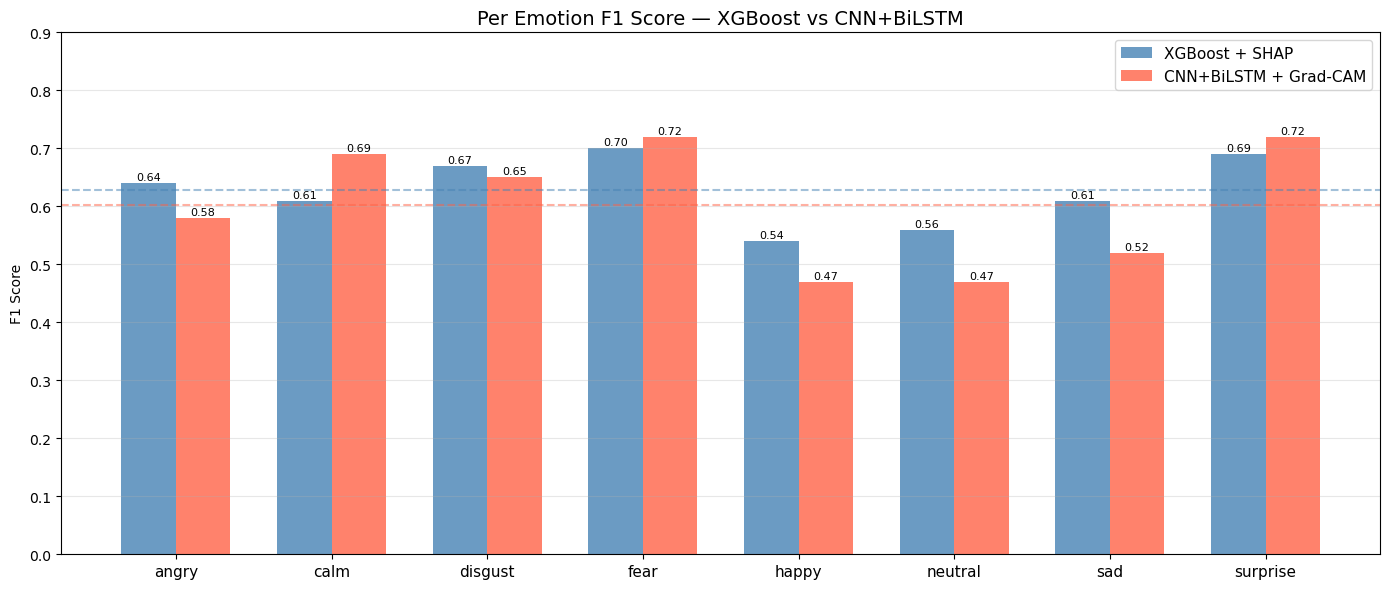

In [54]:
classes = ['angry','calm','disgust','fear',
           'happy','neutral','sad','surprise']

# F1 scores per emotion
xgb_f1  = [0.64, 0.61, 0.67, 0.70, 0.54, 0.56, 0.61, 0.69]
cnn_f1  = [0.58, 0.69, 0.65, 0.72, 0.47, 0.47, 0.52, 0.72]

x     = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - width/2, xgb_f1, width,
               label='XGBoost + SHAP',
               color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, cnn_f1, width,
               label='CNN+BiLSTM + Grad-CAM',
               color='tomato', alpha=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.2f}',
            ha='center', fontsize=8)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.2f}',
            ha='center', fontsize=8)

ax.set_title('Per Emotion F1 Score — XGBoost vs CNN+BiLSTM',
             fontsize=14)
ax.set_ylabel('F1 Score')
ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=11)
ax.set_ylim(0, 0.90)
ax.legend(fontsize=11)
ax.axhline(y=np.mean(xgb_f1), color='steelblue',
           linestyle='--', alpha=0.5,
           label=f'XGBoost mean: {np.mean(xgb_f1):.2f}')
ax.axhline(y=np.mean(cnn_f1), color='tomato',
           linestyle='--', alpha=0.5,
           label=f'CNN mean: {np.mean(cnn_f1):.2f}')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(outputs_path / "final_per_emotion_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()

### 3 — XAI Agreement Summary Table

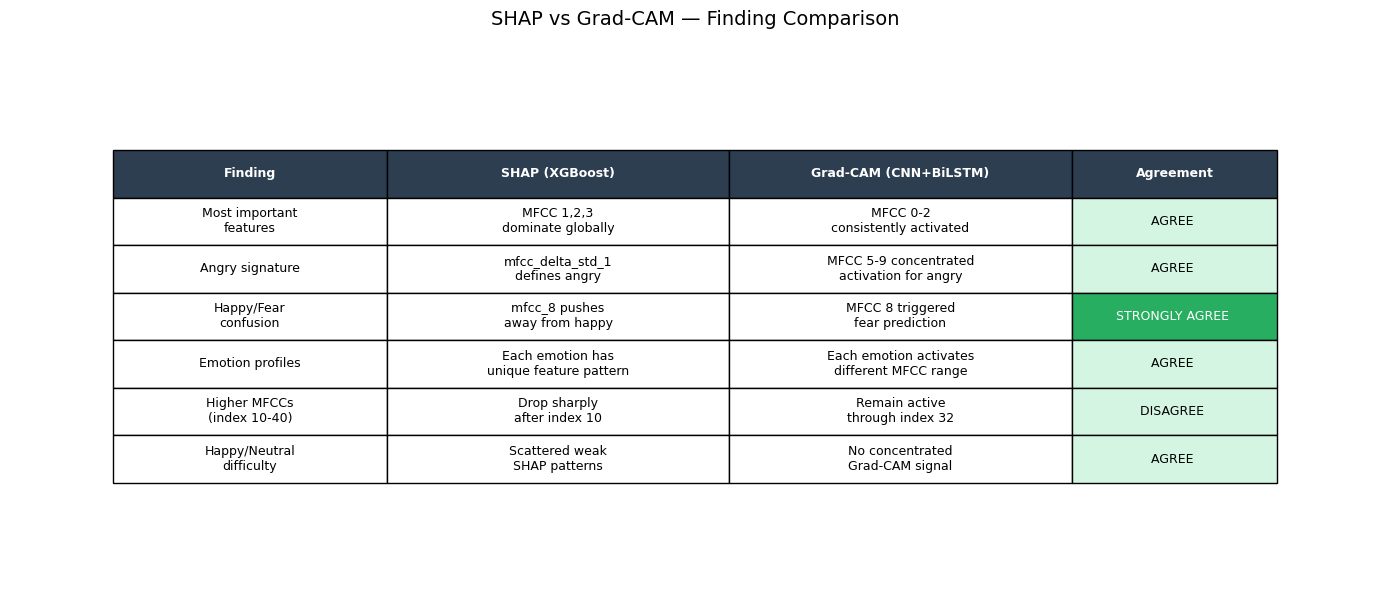

In [57]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

table_data = [
    ['Finding', 'SHAP (XGBoost)', 'Grad-CAM (CNN+BiLSTM)', 'Agreement'],
    ['Most important\nfeatures',
     'MFCC 1,2,3\ndominate globally',
     'MFCC 0-2\nconsistently activated',
     'AGREE '],
    ['Angry signature',
     'mfcc_delta_std_1\ndefines angry',
     'MFCC 5-9 concentrated\nactivation for angry',
     'AGREE '],
    ['Happy/Fear\nconfusion',
     'mfcc_8 pushes\naway from happy',
     'MFCC 8 triggered\nfear prediction',
     'STRONGLY AGREE '],
    ['Emotion profiles',
     'Each emotion has\nunique feature pattern',
     'Each emotion activates\ndifferent MFCC range',
     'AGREE '],
    ['Higher MFCCs\n(index 10-40)',
     'Drop sharply\nafter index 10',
     'Remain active\nthrough index 32',
     'DISAGREE '],
    ['Happy/Neutral\ndifficulty',
     'Scattered weak\nSHAP patterns',
     'No concentrated\nGrad-CAM signal',
     'AGREE '],
]

table = ax.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    cellLoc='center',
    loc='center',
    colWidths=[0.2, 0.25, 0.25, 0.15]
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.5)

# Color header
for j in range(4):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Color agreement column
agree_colors = {
    'AGREE ':          '#d5f5e3',
    'STRONGLY AGREE ': '#27ae60',
    'DISAGREE ':      '#fdebd0'
}
for i in range(1, 7):
    cell_text = table_data[i][3]
    if 'STRONGLY' in cell_text:
        table[i, 3].set_facecolor('#27ae60')
        table[i, 3].set_text_props(color='white')
    elif 'AGREE' in cell_text:
        table[i, 3].set_facecolor('#d5f5e3')
    else:
        table[i, 3].set_facecolor('#fdebd0')

plt.title('SHAP vs Grad-CAM — Finding Comparison',
          fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(outputs_path / "xai_agreement_table.png",
            dpi=150, bbox_inches='tight')
plt.show()

### 4 — Final Summary Dashboard


C:\Users\shahe\AppData\Local\Temp\ipykernel_37444\492674267.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(classes, rotation=45, ha='right', fontsize=8)
C:\Users\shahe\AppData\Local\Temp\ipykernel_37444\492674267.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(classes, rotation=45, ha='right', fontsize=8)
C:\Users\shahe\AppData\Local\Temp\ipykernel_37444\492674267.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(classes, rotation=45, ha='right', fontsize=8)
C:\Users\shahe\AppData\Local\Temp\ipykernel_37444\492674267.py:113: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
C:\Users\shahe\AppData\Local\Temp\ipykerne

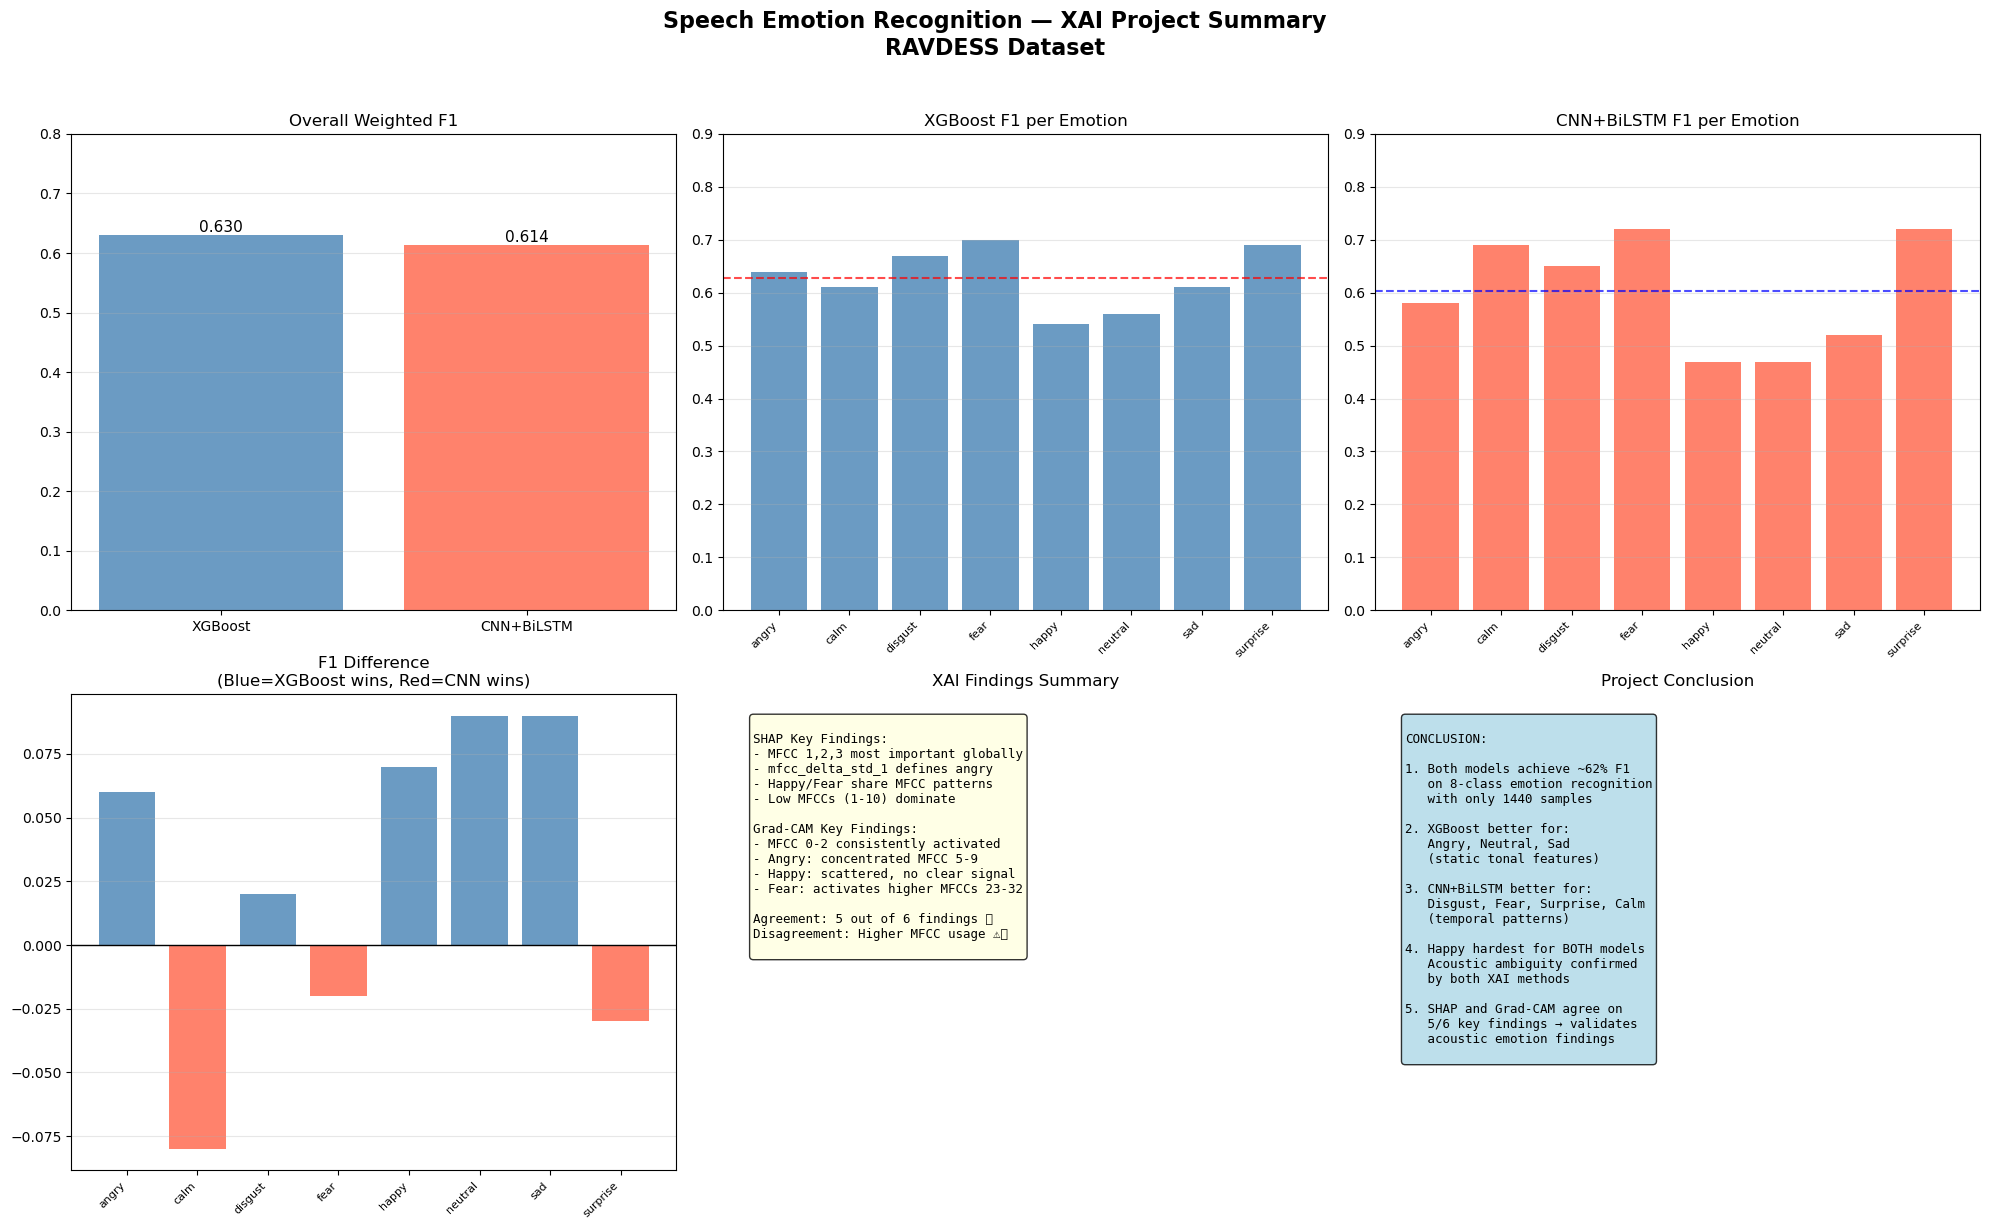

In [58]:
fig = plt.figure(figsize=(20, 12))

# Title
fig.suptitle('Speech Emotion Recognition — XAI Project Summary\nRAVDESS Dataset',
             fontsize=16, fontweight='bold', y=1.02)

# Plot 1 — Overall accuracy
ax1 = fig.add_subplot(2, 3, 1)
models_names = ['XGBoost', 'CNN+BiLSTM']
f1_vals      = [0.630, 0.614]
colors       = ['steelblue', 'tomato']
bars         = ax1.bar(models_names, f1_vals,
                       color=colors, alpha=0.8)
for bar, val in zip(bars, f1_vals):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=11)
ax1.set_title('Overall Weighted F1')
ax1.set_ylim(0, 0.80)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2 — XGBoost per emotion
ax2 = fig.add_subplot(2, 3, 2)
ax2.bar(classes, xgb_f1, color='steelblue', alpha=0.8)
ax2.set_title('XGBoost F1 per Emotion')
ax2.set_xticklabels(classes, rotation=45, ha='right', fontsize=8)
ax2.set_ylim(0, 0.90)
ax2.axhline(y=np.mean(xgb_f1), color='red',
            linestyle='--', alpha=0.7)
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3 — CNN+BiLSTM per emotion
ax3 = fig.add_subplot(2, 3, 3)
ax3.bar(classes, cnn_f1, color='tomato', alpha=0.8)
ax3.set_title('CNN+BiLSTM F1 per Emotion')
ax3.set_xticklabels(classes, rotation=45, ha='right', fontsize=8)
ax3.set_ylim(0, 0.90)
ax3.axhline(y=np.mean(cnn_f1), color='blue',
            linestyle='--', alpha=0.7)
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4 — Which model wins per emotion
ax4 = fig.add_subplot(2, 3, 4)
diff = [x - c for x, c in zip(xgb_f1, cnn_f1)]
bar_colors = ['steelblue' if d > 0 else 'tomato' for d in diff]
ax4.bar(classes, diff, color=bar_colors, alpha=0.8)
ax4.axhline(y=0, color='black', linewidth=1)
ax4.set_title('F1 Difference\n(Blue=XGBoost wins, Red=CNN wins)')
ax4.set_xticklabels(classes, rotation=45, ha='right', fontsize=8)
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5 — XAI method summary text
ax5 = fig.add_subplot(2, 3, 5)
ax5.axis('off')
summary_text = """
SHAP Key Findings:
- MFCC 1,2,3 most important globally
- mfcc_delta_std_1 defines angry
- Happy/Fear share MFCC patterns
- Low MFCCs (1-10) dominate

Grad-CAM Key Findings:
- MFCC 0-2 consistently activated
- Angry: concentrated MFCC 5-9
- Happy: scattered, no clear signal
- Fear: activates higher MFCCs 23-32

Agreement: 5 out of 6 findings 
Disagreement: Higher MFCC usage 
"""
ax5.text(0.05, 0.95, summary_text,
         transform=ax5.transAxes,
         fontsize=9, verticalalignment='top',
         fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow',
                   alpha=0.8))
ax5.set_title('XAI Findings Summary')

# Plot 6 — Conclusion text
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
conclusion_text = """
CONCLUSION:

1. Both models achieve ~62% F1
   on 8-class emotion recognition
   with only 1440 samples

2. XGBoost better for:
   Angry, Neutral, Sad
   (static tonal features)

3. CNN+BiLSTM better for:
   Disgust, Fear, Surprise, Calm
   (temporal patterns)

4. Happy hardest for BOTH models
   Acoustic ambiguity confirmed
   by both XAI methods

5. SHAP and Grad-CAM agree on
   5/6 key findings → validates
   acoustic emotion findings
"""
ax6.text(0.05, 0.95, conclusion_text,
         transform=ax6.transAxes,
         fontsize=9, verticalalignment='top',
         fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue',
                   alpha=0.8))
ax6.set_title('Project Conclusion')

plt.tight_layout()
plt.savefig(outputs_path / "final_summary_dashboard.png",
            dpi=150, bbox_inches='tight')
plt.show()

### 5 — Save Final Comparison Report

In [59]:
# Save all numbers for report
import json

final_results = {
    "XGBoost": {
        "accuracy":    0.632,
        "weighted_f1": 0.630,
        "per_emotion_f1": dict(zip(classes, xgb_f1)),
        "xai_method":  "SHAP"
    },
    "CNN_BiLSTM": {
        "accuracy":    0.620,
        "weighted_f1": 0.614,
        "per_emotion_f1": dict(zip(classes, cnn_f1)),
        "xai_method":  "Grad-CAM"
    },
    "xai_agreement": {
        "total_findings":   6,
        "agreements":       5,
        "disagreements":    1,
        "agreement_rate":   "83.3%"
    },
    "key_finding": "MFCC 8 identified as critical"
                   " for happy/fear confusion"
                   " by both SHAP and Grad-CAM independently"
}

with open(outputs_path / "final_results.json", "w") as f:
    json.dump(final_results, f, indent=4)

print("Final results saved ")

Final results saved 
